In [8]:
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from ultralytics import YOLO
from PIL import Image
import os
import cv2

card_names = ['10c', '10d', '10h', '10s', '2c', '2d', '2h', '2s', 
              '3c', '3d', '3h', '3s', '4c', '4d', '4h', '4s',
              '5c', '5d', '5h', '5s', '6c', '6d', '6h', '6s',
              '7c', '7d', '7h', '7s', '8c', '8d', '8h', '8s',
              '9c', '9d', '9h', '9s', 'Ac', 'Ad', 'Ah', 'As',
              'Jc', 'Jd', 'Jh', 'Js', 'Kc', 'Kd', 'Kh', 'Ks',
              'Qc', 'Qd', 'Qh', 'Qs']


In [ ]:
def get_free_gpu():
    if not torch.cuda.is_available():
        return torch.device("cpu")

    free_mem = []
    for i in range(torch.cuda.device_count()):
        torch.cuda.set_device(i)
        torch.cuda.empty_cache()
        stats = torch.cuda.mem_get_info(i)
        free_mem.append((stats[0], i))  

    _, best_gpu = max(free_mem)
    return torch.device(f"cuda:{best_gpu}")

device = get_free_gpu()

# Load YOLO
yolo_model = YOLO('/work/csse463/202620/03/runs/detect/train26/weights/best.pt')

# Rebuild CNN architecture 
num_classes = 52  # playing cards
cnn_model = resnet18(weights=None)
cnn_model.conv1 = nn.Conv2d(
    3, 64, kernel_size=3, stride=1, padding=1, bias=False
)
cnn_model.maxpool = nn.Identity()
cnn_model.fc = nn.Linear(cnn_model.fc.in_features, num_classes)

# Load trained weights
cnn_model.load_state_dict(
    torch.load("cnn_resnet18_224x224_3.pt", map_location=device)
)
cnn_model.to(device)
cnn_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

In [ ]:
# Transform for CNN
weights = ResNet18_Weights.IMAGENET1K_V1  # ImageNet normalization
cnn_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet input size
    transforms.ToTensor(),
    transforms.Normalize(
        mean=weights.transforms().mean,
        std=weights.transforms().std)
])

def detect_and_classify(image_path):
    image = cv2.imread(image_path)  # Load image (BGR)

    if image is None:
        print(f"Failed to load image: {image_path}")
        return None, []
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB

    results = yolo_model(image_rgb)  # Run YOLO detection
    boxes = results[0].boxes.xyxy.cpu().numpy()  # Bounding boxes

    predictions = []

    for box in boxes:
        x1, y1, x2, y2 = map(int, box)

        crop = image_rgb[y1:y2, x1:x2]  # Crop detected region
        crop_pil = Image.fromarray(crop)
        input_tensor = cnn_transform(crop_pil).unsqueeze(0).to(device)  # Prepare for CNN

        with torch.no_grad():
            outputs = cnn_model(input_tensor)
            _, pred = torch.max(outputs, 1)  # Predicted class

        class_id = pred.item()
        card_label = card_names[class_id]

        predictions.append({
            "box": (x1, y1, x2, y2),
            "class_id": class_id,
            "card": card_label
        })

        # Draw bounding box + label
        cv2.rectangle(image, (x1, y1), (x2, y2), (0,255,0), 2)
        cv2.putText(image, card_label, (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

    return image, predictions


0: 416x416 1 10c, 1 Ah, 1 Js, 9.1ms
Speed: 17.6ms preprocess, 9.1ms inference, 1.9ms postprocess per image at shape (1, 3, 416, 416)


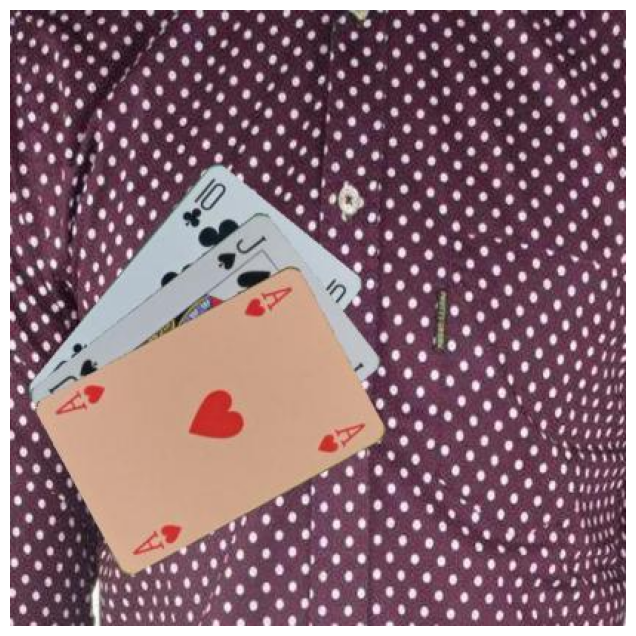

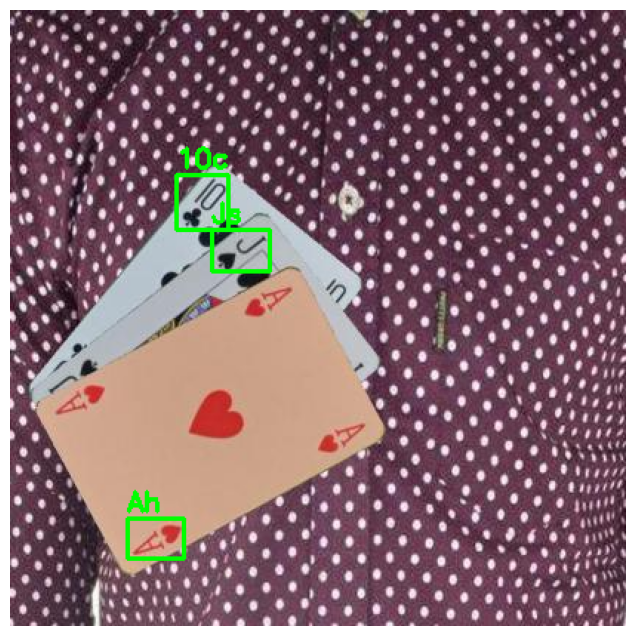

In [ ]:
import matplotlib.pyplot as plt

# Run detection + classification
output_image, predictions = detect_and_classify(
    "./test/images/980259162_jpg.rf.8eea39fcfd6d1685419e941cf7861199.jpg"
)

# Load original image for comparison
img = cv2.imread("./test/images/980259162_jpg.rf.8eea39fcfd6d1685419e941cf7861199.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB for matplotlib

# Show original image
plt.figure(figsize=(8,8))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

# Show image with detections drawn
plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()




0: 416x416 2 Kcs, 8.9ms
Speed: 19.4ms preprocess, 8.9ms inference, 1.9ms postprocess per image at shape (1, 3, 416, 416)

0: 416x416 1 10d, 2 10ss, 1 Qc, 8.4ms
Speed: 1.1ms preprocess, 8.4ms inference, 1.3ms postprocess per image at shape (1, 3, 416, 416)

0: 416x416 2 Jcs, 1 Jd, 1 Js, 1 Ks, 7.5ms
Speed: 1.1ms preprocess, 7.5ms inference, 1.3ms postprocess per image at shape (1, 3, 416, 416)

0: 416x416 1 Js, 1 Qc, 7.0ms
Speed: 1.0ms preprocess, 7.0ms inference, 1.3ms postprocess per image at shape (1, 3, 416, 416)

0: 416x416 2 4cs, 7.4ms
Speed: 0.9ms preprocess, 7.4ms inference, 1.4ms postprocess per image at shape (1, 3, 416, 416)

0: 416x416 1 4s, 1 7s, 7.0ms
Speed: 0.9ms preprocess, 7.0ms inference, 1.3ms postprocess per image at shape (1, 3, 416, 416)

0: 416x416 1 4s, 4 8ss, 6.7ms
Speed: 1.0ms preprocess, 6.7ms inference, 1.2ms postprocess per image at shape (1, 3, 416, 416)

0: 416x416 1 5c, 1 5s, 2 8ss, 6.9ms
Speed: 0.9ms preprocess, 6.9ms inference, 1.2ms postprocess per ima

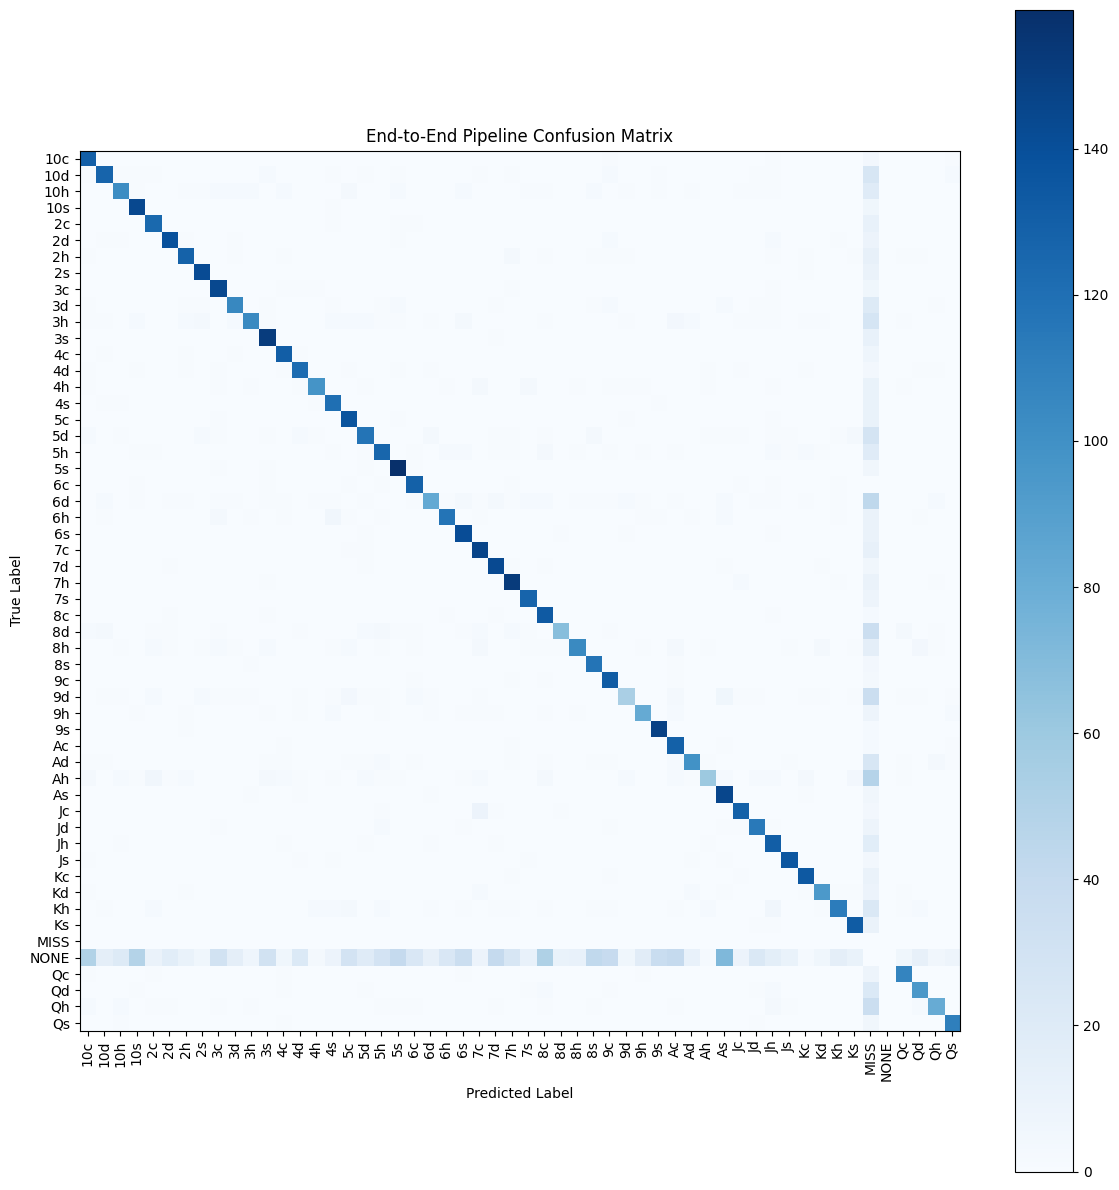

In [ ]:
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

def evaluate_pipeline_full(test_root):
    images_path = os.path.join(test_root, "images")
    labels_path = os.path.join(test_root, "labels")

    total_cards = 0
    correct_cards = 0

    y_true = []
    y_pred = []

    for img_name in tqdm(os.listdir(images_path), disable=True):
        img_path = os.path.join(images_path, img_name)
        label_path = os.path.join(
            labels_path,
            img_name.replace(".jpg", ".txt")
        )

        # --- Ground Truth ---
        true_cards = []
        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f:
                    class_id = int(line.split()[0])  # YOLO class id
                    true_cards.append(card_names[class_id])

        # --- Run full pipeline (YOLO + CNN) ---
        _, predictions = detect_and_classify(img_path)
        predicted_cards = [p["card"] for p in predictions]

        total_cards += len(true_cards)

        # --- Multiset matching for accuracy ---
        preds_copy = predicted_cards.copy()
        for card in true_cards:
            if card in preds_copy:
                correct_cards += 1
                preds_copy.remove(card)

        # --- Build confusion matrix entries ---
        preds_copy = predicted_cards.copy()
        for card in true_cards:
            if card in preds_copy:
                y_true.append(card)
                y_pred.append(card)
                preds_copy.remove(card)
            elif len(preds_copy) > 0:
                wrong_pred = preds_copy.pop(0)  # Wrong prediction
                y_true.append(card)
                y_pred.append(wrong_pred)
            else:
                y_true.append(card)
                y_pred.append("MISS")  # No prediction

        # Extra predictions (false positives)
        for extra_pred in preds_copy:
            y_true.append("NONE")
            y_pred.append(extra_pred)

    accuracy = correct_cards / total_cards

    print("\n===== Pipeline Results =====")
    print(f"Total Cards: {total_cards}")
    print(f"Correct Cards: {correct_cards}")
    print(f"End-to-End Accuracy: {accuracy:.4f}")

    return accuracy, y_true, y_pred


# --- Run Evaluation ---
accuracy, y_true, y_pred = evaluate_pipeline_full("./test/")

# --- Build Confusion Matrix ---
labels = sorted(list(set(y_true + y_pred)))  # All observed labels
cm = confusion_matrix(y_true, y_pred, labels=labels)

# --- Plot Heatmap ---
plt.figure(figsize=(12,12))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("End-to-End Pipeline Confusion Matrix")
plt.tight_layout()
plt.show()